**1D van der Pol Oscillator**

In [1]:
from van_der_pol_oscillator_1d import ReverseTimeVanDerPolOscillator1D
import immrax as irx
import jax
import jax.numpy as jnp
reverse_vdp = ReverseTimeVanDerPolOscillator1D()

In [2]:
from typing import Tuple
jax.devices()

[CudaDevice(id=0)]

In [3]:
sys_mjacM = irx.mjacM(reverse_vdp.f)


In [ ]:
Ms = sys_mjacM(jnp.zeros(1), irx.icentpert(jnp.zeros(2), jnp.array([1, 0])), 
               centers=((jnp.zeros(1), jnp.zeros(2)),), permutations=(irx.Permutation((0, 2, 1)), irx.Permutation((1, 2, 0))))

print(Ms[0][1])
print(Ms[1][1])


[[[( 0.,  0.)]
  [(-1., -1.)]]

 [[( 1.,  1.)]
  [(-1., -1.)]]]
[[[( 0.,  0.)]
  [(-1., -1.)]]

 [[( 1.,  1.)]
  [(-1., -1.)]]]


In [5]:
A_list_rtvdp = irx.get_sparse_corners(Ms[1][1])
print(A_list_rtvdp)

[Array([[ 0., -1.],
       [ 1., -1.]], dtype=float32)]


(2, 2)
(2, 2)
P_value for 1th order is: 
[[ 9.99999999e-01 -2.01051804e-06]
 [-2.01051804e-06  1.00215079e+00]]
(32, 32)
(32, 6)
P_value for 5th order is: 
[[ 1.00000000e+00 -2.54949029e-05 -3.81392206e-05  2.25927223e-07
   1.56190193e-06 -1.99982113e-06]
 [-2.54949029e-05  5.00179019e+00  1.32579374e-03 -1.40792620e-03
   1.68973444e-04 -1.54767023e-04]
 [-3.81392206e-05  1.32579374e-03  4.63531472e+00 -5.37801985e-01
   2.37821216e-01 -2.15535730e-02]
 [ 2.25927223e-07 -1.40792620e-03 -5.37801985e-01  3.20822732e+00
   2.49661099e-01  1.02591627e-01]
 [ 1.56190193e-06  1.68973444e-04  2.37821216e-01  2.49661099e-01
   2.48421996e+00  3.58683918e-01]
 [-1.99982113e-06 -1.54767023e-04 -2.15535730e-02  1.02591627e-01
   3.58683918e-01  1.97877834e+00]]
(256, 256)
(256, 9)
P_value for 8th order is: 
[[ 1.00000000e+00 -6.43436549e-05  6.03959284e-05 -2.15413403e-06
  -1.31911259e-05  1.05695577e-05 -5.82838764e-06  1.53530773e-06
  -6.24116042e-07]
 [-6.43436549e-05  8.00001095e+00 -6.09

/home/user/output_feedback/nhholyap/homogeneous_higher_order_lyapunov_functions.py:212: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=12)


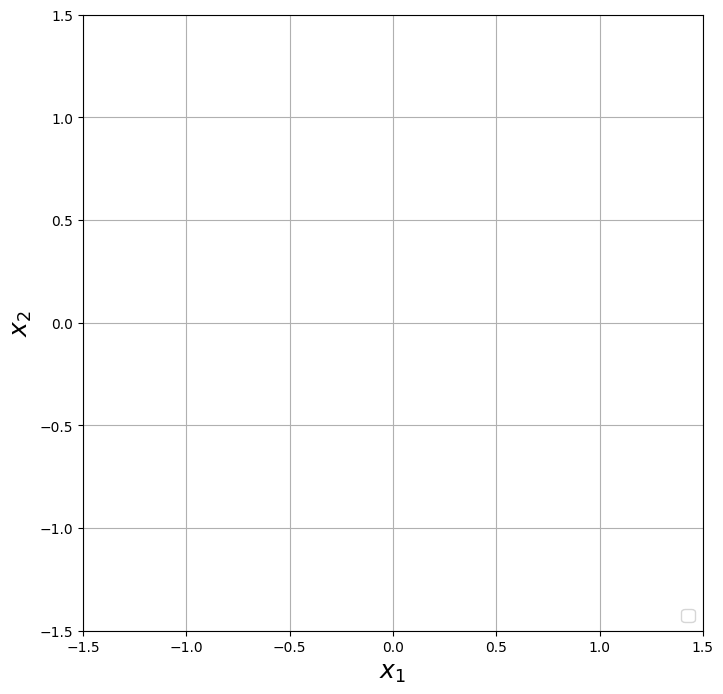

In [6]:
import sys, os
sys.path.append(os.path.abspath(".."))

from homogeneous_higher_order_lyapunov_functions import plot_reachable_set_from_hierarchical_lyap_func
plot_reachable_set_from_hierarchical_lyap_func(A_list=A_list_rtvdp, x0=jnp.zeros(2))

In [7]:
from homogeneous_higher_order_lyapunov_functions import calculate_lyapunov_P_matrix
calculate_lyapunov_P_matrix(1, A_list=A_list_rtvdp)

array([[ 9.99999999e-01, -2.01051804e-06],
       [-2.01051804e-06,  1.00215079e+00]])

(2, 2)
(2, 2)
(32, 32)
(32, 6)
(256, 256)
(256, 9)


/home/user/anaconda3/envs/immrax/lib/python3.11/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


(512, 512)
(512, 10)


/home/user/output_feedback/nhholyap/homogeneous_higher_order_lyapunov_functions.py:209: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=12)


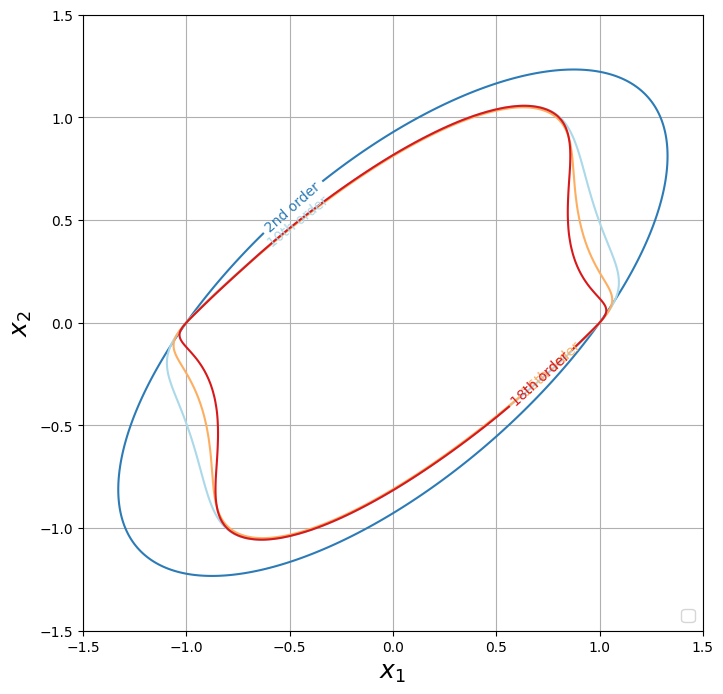

In [7]:
# Define system matrices for switched modes
A1 = jnp.array([[-0.5, 0.5], [-0.5, -0.5]])
A2 = jnp.array([[-2.5, 2.5], [-2.5, 1.5]])
x0_abate = jnp.array([1, 0])  # Initial condition
A_list_abate = [A1, A2]
plot_reachable_set_from_hierarchical_lyap_func(A_list=A_list_abate, x0=x0_abate, )